In [1]:
"""
==========================================================================
 Dynamic Inventory Replenishment - Synthetic Environment Data Generator
 -------------------------------------------------------------------------
 Purpose:
   Generates a 365-day synthetic retail-demand "environment" dataset that
   will later be used to solve the Bellman Equation (Value Iteration) for
   an optimal (s, S) inventory replenishment policy.

 Demand-generation logic combines three ideas from the case study:
   1. Poisson-style baseline demand      -> approximated as r (NB size) -> large
   2. Negative-Binomial overdispersion   -> captures "bursty" demand (Promo days)
   3. Markov-modulated day-type regime   -> Weekday / Weekend / Promo state,
                                             which drives lambda_t and variance

 Output:
   /mnt/user-data/outputs/simulated_retail_demand.csv   (365 rows x 9 cols)

 Columns:
   day_id               int      Sequential day index (1-365)
   date                 date     Calendar date
   day_type             str      Weekday / Weekend / Promo (Markov-modulated)
   base_lambda          float    Expected demand intensity (lambda_t) for the day
   overdispersion_r     float    NB "size" parameter (variance control; low = bursty)
   simulated_demand     int      Actual sampled demand units for the day
   supplier_lead_time   int      Days for a placed order to arrive
   unit_holding_cost    float    $ cost of holding one unit of stock for one day
   unit_stockout_cost   float    $ lost-margin cost per unit of unmet demand
==========================================================================
"""

import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------------
# 0. Reproducibility
# ------------------------------------------------------------------
SEED = 42
rng = np.random.default_rng(SEED)

N_DAYS = 365
START_DATE = "2025-01-01"

# ------------------------------------------------------------------
# 1. Markov-modulated day-type regime
#    Calendar decides Weekday/Weekend; a 2-state Markov chain overlays
#    "Promo" bursts of ~2-4 days (flash sales / holiday campaigns),
#    which overrides the calendar-based label for that day.
# ------------------------------------------------------------------
dates = pd.date_range(start=START_DATE, periods=N_DAYS, freq="D")

promo_state = 0            # 0 = no promo, 1 = promo active
P_ENTER_PROMO = 0.025       # ~9 promo campaigns per year
P_STAY_PROMO  = 0.55        # average promo length ~2.2 days

day_types = []
for d in dates:
    if promo_state == 1:
        promo_state = 1 if rng.random() < P_STAY_PROMO else 0
    else:
        promo_state = 1 if rng.random() < P_ENTER_PROMO else 0

    if promo_state == 1:
        day_types.append("Promo")
    elif d.dayofweek >= 5:          # Saturday=5, Sunday=6
        day_types.append("Weekend")
    else:
        day_types.append("Weekday")

# ------------------------------------------------------------------
# 2. Base demand intensity: lambda_t = lambda_base * factor(day_type) + noise
# ------------------------------------------------------------------
LAMBDA_BASE = 8.5
DAY_TYPE_FACTOR = {"Weekday": 1.00, "Weekend": 1.40, "Promo": 2.70}
NOISE_SD = 0.60

base_lambda = np.array([
    LAMBDA_BASE * DAY_TYPE_FACTOR[dt] + rng.normal(0, NOISE_SD)
    for dt in day_types
])
base_lambda = np.clip(base_lambda, 1.0, None)     # intensity must stay positive

# ------------------------------------------------------------------
# 3. Overdispersion parameter r (Negative-Binomial "size")
#    Large r  -> NB approaches Poisson (steady, low-variance demand)
#    Small r  -> heavy-tailed, "bursty" demand (typical of Promo days)
#    Parameterization: NB(mean=mu, size=r)  =>  Var = mu + mu^2 / r
# ------------------------------------------------------------------
R_BY_TYPE = {"Weekday": 18.0, "Weekend": 12.0, "Promo": 4.0}
r_param = np.array([
    max(2.0, R_BY_TYPE[dt] + rng.normal(0, 1.5)) for dt in day_types
])

# ------------------------------------------------------------------
# 4. Sample simulated_demand ~ NegativeBinomial(mean=base_lambda, size=r)
#    numpy negative_binomial(n, p) uses n = r, p = r / (r + mu)
# ------------------------------------------------------------------
p_param = r_param / (r_param + base_lambda)
simulated_demand = rng.negative_binomial(n=r_param, p=p_param).astype(int)

# ------------------------------------------------------------------
# 5. Supplier lead time (days) - mostly 1-2 days, rare disruption spikes
# ------------------------------------------------------------------
lead_time_choices = [1, 2, 3, 5]
lead_time_probs   = [0.55, 0.30, 0.10, 0.05]
supplier_lead_time = rng.choice(lead_time_choices, size=N_DAYS, p=lead_time_probs)

# ------------------------------------------------------------------
# 6. Cost parameters (needed later inside the Bellman reward function)
#    Small daily noise around a stable base cost reflects minor real-world
#    fluctuation in storage/logistics pricing and stockout opportunity cost.
# ------------------------------------------------------------------
HOLDING_COST_BASE  = 2.0      # $ per unit held per day
STOCKOUT_COST_BASE = 8.0      # $ lost margin per unit of unmet demand

unit_holding_cost = np.clip(
    np.round(rng.normal(HOLDING_COST_BASE, 0.15, N_DAYS), 2), 1.0, None
)

stockout_cost_factor = np.array([1.3 if dt == "Promo" else 1.0 for dt in day_types])
unit_stockout_cost = np.clip(
    np.round(rng.normal(STOCKOUT_COST_BASE, 0.5, N_DAYS) * stockout_cost_factor, 2),
    3.0, None
)

# ------------------------------------------------------------------
# 7. Assemble + preprocess the DataFrame
# ------------------------------------------------------------------
df = pd.DataFrame({
    "day_id": np.arange(1, N_DAYS + 1),
    "date": dates,
    "day_type": day_types,
    "base_lambda": np.round(base_lambda, 3),
    "overdispersion_r": np.round(r_param, 2),
    "simulated_demand": simulated_demand,
    "supplier_lead_time": supplier_lead_time,
    "unit_holding_cost": unit_holding_cost,
    "unit_stockout_cost": unit_stockout_cost,
})

# --- integrity checks / preprocessing -----------------------------
assert df.shape == (365, 9), "Dataset must be exactly 365 rows x 9 columns"
assert df.isna().sum().sum() == 0, "No missing values allowed"
assert (df["simulated_demand"] >= 0).all(), "Demand cannot be negative"
assert df["day_id"].is_unique, "day_id must be unique"

df["date"] = pd.to_datetime(df["date"]).dt.date        # clean date dtype
df["day_type"] = df["day_type"].astype("category")
df = df.sort_values("day_id").reset_index(drop=True)

# ------------------------------------------------------------------
# 8. Save to CSV
# ------------------------------------------------------------------
OUT_PATH = Path("/mnt/user-data/outputs/simulated_retail_demand.csv")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_PATH, index=False)

print(f"Saved {len(df)} rows x {df.shape[1]} columns -> {OUT_PATH}")
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst 10 rows:")
print(df.head(10).to_string(index=False))
print("\nDay-type distribution:")
print(df["day_type"].value_counts())
print("\nQuick demand stats by day_type:")
print(df.groupby("day_type", observed=True)["simulated_demand"].agg(["mean", "std", "min", "max"]))

Saved 365 rows x 9 columns -> \mnt\user-data\outputs\simulated_retail_demand.csv

Column dtypes:
day_id                   int64
date                    object
day_type              category
base_lambda            float64
overdispersion_r       float64
simulated_demand         int64
supplier_lead_time       int64
unit_holding_cost      float64
unit_stockout_cost     float64
dtype: object

First 10 rows:
 day_id       date day_type  base_lambda  overdispersion_r  simulated_demand  supplier_lead_time  unit_holding_cost  unit_stockout_cost
      1 2025-01-01  Weekday        9.008             15.65                10                   2               2.05                7.16
      2 2025-01-02  Weekday        8.157             19.03                 7                   2               2.07                8.35
      3 2025-01-03  Weekday        8.988             17.47                12                   1               2.16                7.52
      4 2025-01-04  Weekend       12.541          

In [3]:
csv_path = "/mnt/user-data/outputs/simulated_retail_demand.csv"
print(csv_path)

/mnt/user-data/outputs/simulated_retail_demand.csv


In [14]:
"""
==========================================================================
 Dynamic Inventory Replenishment - MDP / Bellman-Equation Solver
 -------------------------------------------------------------------------
 This is the CORE MODEL: it formulates the retail replenishment problem
 as a Markov Decision Process and solves it with Value Iteration on the
 Bellman Equation to obtain the optimal (s, S) ordering policy.

 (Episode simulation / cumulative reward / penalty tracking is a
 separate, later step that consumes the outputs of this script.)

 ---------------------------------------------------------------
 MDP FORMULATION
 ---------------------------------------------------------------
 State      : (I, R)
               I = on-hand inventory, discretized 0..I_MAX
               R = demand regime  in {Weekday, Weekend, Promo}
                   -> this is the "Markov-modulated" part: R evolves
                      according to a Markov chain, estimated empirically
                      from the synthetic dataset's day_type sequence.

 Action     : a = order quantity, a in {0, 1, ..., I_MAX - I}
              (order arrives immediately -> "available" stock = I + a)

 Demand     : D | R ~ Negative Binomial(mean = mu_R, size = r_R)
              -> captures the high-variance / "bursty" behaviour
                 explicitly called out in the case-study context
                 (over-dispersion parameter r_R fit per regime).

 Transition : I' = clip(I + a - D, 0, I_MAX)
              R' ~ P_regime[R, :]                (Markov chain, indep. of I,a)

 Reward     : r(I,a,R,D) = - K*1{a>0}                (fixed order cost)
                            - c*a                     (variable order cost)
                            - h_R * max(0, I+a-D)      (holding cost)
                            - p_R * max(0, D-(I+a))    (stockout / lost-sale cost)

 Bellman Equation (infinite horizon, discounted):
   V(I,R) = max_a  E_D[ r(I,a,R,D) ] + gamma * sum_R' P(R'|R) * E_D[ V(I',R') ]

 Solved via Value Iteration until ||V_new - V||_inf < THETA.
 ---------------------------------------------------------------
 NOTE / MODELING ASSUMPTION: supplier_lead_time is present in the dataset
 for realism but is treated here as effectively 1 day (order placed today
 is available for tomorrow's demand). Extending the state with an explicit
 "pipeline/in-transit" dimension is a natural next iteration of this model.
==========================================================================
"""

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import nbinom

# ==========================================================
# 0. Load the synthetic environment dataset
# ==========================================================
DATA_PATH = "/mnt/user-data/outputs/simulated_retail_demand.csv"
df = pd.read_csv(DATA_PATH)
df["day_type"] = df["day_type"].astype(str)

REGIMES = ["Weekday", "Weekend", "Promo"]
R_IDX = {name: i for i, name in enumerate(REGIMES)}
N_R = len(REGIMES)

# ==========================================================
# 1. Estimate the Markov regime-transition matrix P(R'|R)
#    directly from the observed day_type sequence
# ==========================================================
trans_counts = np.zeros((N_R, N_R))
types = df["day_type"].to_numpy()
for t in range(len(types) - 1):
    trans_counts[R_IDX[types[t]], R_IDX[types[t + 1]]] += 1
P_regime = trans_counts / trans_counts.sum(axis=1, keepdims=True)

# ==========================================================
# 2. Fit a Negative-Binomial demand distribution per regime
#    Method of moments: mu = mean, r = mu^2 / (var - mu)
#    (falls back to a near-Poisson r if var <= mu)
# ==========================================================
D_MAX = 60  # truncation point; remaining probability mass lumped at D_MAX

demand_pmf    = np.zeros((N_R, D_MAX + 1))
holding_cost  = np.zeros(N_R)
stockout_cost = np.zeros(N_R)

for name, idx in R_IDX.items():
    sub = df.loc[df["day_type"] == name, "simulated_demand"]
    mu, var = sub.mean(), sub.var()
    r_nb = (mu ** 2 / (var - mu)) if var > mu else 1e6
    p_nb = r_nb / (r_nb + mu)

    ks = np.arange(0, D_MAX)
    pmf = nbinom.pmf(ks, r_nb, p_nb)
    pmf = np.append(pmf, max(0.0, 1.0 - pmf.sum()))   # tail mass -> D_MAX
    demand_pmf[idx] = pmf / pmf.sum()

    holding_cost[idx]  = df.loc[df["day_type"] == name, "unit_holding_cost"].mean()
    stockout_cost[idx] = df.loc[df["day_type"] == name, "unit_stockout_cost"].mean()

# ==========================================================
# 3. MDP hyperparameters
# ==========================================================
I_MAX = 50                 # max on-hand inventory capacity (units)
GAMMA = 0.95                # discount factor
ORDER_FIXED_COST = 20.0     # K: fixed cost incurred whenever an order is placed
ORDER_UNIT_COST  = 1.0      # c: variable purchase cost per unit ordered
THETA = 1e-3                 # convergence threshold on max value change
MAX_ITERS = 1000

inv_levels    = np.arange(0, I_MAX + 1)
demand_levels = np.arange(0, D_MAX + 1)

# Precompute, for every possible "available stock" level (I+a) and every
# demand outcome D: next inventory, leftover (held) units, shortfall units.
avail_grid, d_grid = np.meshgrid(inv_levels, demand_levels, indexing="ij")
next_I    = np.clip(avail_grid - d_grid, 0, I_MAX)     # (I_MAX+1, D_MAX+1)
leftover  = np.clip(avail_grid - d_grid, 0, None)       # units held overnight
shortfall = np.clip(d_grid - avail_grid, 0, None)        # unmet demand units

# ==========================================================
# 4. Value Iteration (vectorized Bellman backup)
#    Exploits K-convexity: for a fixed 'available' target level, the
#    problem reduces to choosing the best "available" via a suffix-max
#    scan, which is the efficient, textbook way to solve (s,S) MDPs
#    exactly (no brute-force loop over every action).
# ==========================================================
V = np.zeros((N_R, I_MAX + 1))
policy_order_upto = np.zeros((N_R, I_MAX + 1), dtype=int)   # target "available" level
policy_order_qty  = np.zeros((N_R, I_MAX + 1), dtype=int)   # a* = order_upto - I

for iteration in range(1, MAX_ITERS + 1):
    V_new = np.zeros_like(V)

    for r in range(N_R):
        pmf = demand_pmf[r]
        V_next_regime_avg = P_regime[r] @ V                  # E_R'[V(.,R')], shape (I_MAX+1,)

        V_gather = V_next_regime_avg[next_I]                  # (I_MAX+1, D_MAX+1)
        expected_future    = V_gather @ pmf
        expected_holding    = leftover  @ pmf
        expected_stockout   = shortfall @ pmf

        # G(available) = expected one-step reward + discounted continuation,
        # as a function of the post-order stock level ("available")
        G = (-holding_cost[r] * expected_holding
             - stockout_cost[r] * expected_stockout
             + GAMMA * expected_future)

        H = G - ORDER_UNIT_COST * inv_levels                   # strip out variable cost*available

        # suffix max / argmax of H over available = i..I_MAX
        suffix_max = np.empty(I_MAX + 1)
        suffix_argmax = np.empty(I_MAX + 1, dtype=int)
        best_val, best_idx = -np.inf, I_MAX
        for i in range(I_MAX, -1, -1):
            if H[i] >= best_val:
                best_val, best_idx = H[i], i
            suffix_max[i] = best_val
            suffix_argmax[i] = best_idx

        for I in inv_levels:
            no_order_value = G[I]                                # action a = 0
            if I < I_MAX:
                order_value  = suffix_max[I + 1] + ORDER_UNIT_COST * I - ORDER_FIXED_COST
                order_target = suffix_argmax[I + 1]
            else:
                order_value, order_target = -np.inf, I

            if order_value > no_order_value:
                V_new[r, I] = order_value
                policy_order_upto[r, I] = order_target
                policy_order_qty[r, I]  = order_target - I
            else:
                V_new[r, I] = no_order_value
                policy_order_upto[r, I] = I
                policy_order_qty[r, I]  = 0

    delta = np.max(np.abs(V_new - V))
    V = V_new
    if delta < THETA:
        print(f"Value Iteration converged after {iteration} iterations (delta={delta:.6f})")
        break
else:
    print(f"Reached MAX_ITERS={MAX_ITERS} without full convergence (delta={delta:.6f})")

# ==========================================================
# 5. Extract the optimal (s, S) policy per regime
#    s = reorder point (order whenever I <= s)
#    S = order-up-to level (target stock after ordering)
# ==========================================================
sS_rows = []
for name, idx in R_IDX.items():
    order_mask = policy_order_qty[idx] > 0
    if order_mask.any():
        s_level = int(inv_levels[order_mask].max())
        S_level = int(round(policy_order_upto[idx][order_mask].mean()))
    else:
        s_level, S_level = 0, 0
    sS_rows.append({
        "day_type": name,
        "reorder_point_s": s_level,
        "order_up_to_S": S_level,
        "avg_holding_cost": round(float(holding_cost[idx]), 3),
        "avg_stockout_cost": round(float(stockout_cost[idx]), 3),
        "fitted_demand_mean": round(float(df.loc[df.day_type == name, "simulated_demand"].mean()), 3),
        "fitted_demand_std": round(float(df.loc[df.day_type == name, "simulated_demand"].std()), 3),
    })
sS_df = pd.DataFrame(sS_rows)

# ==========================================================
# 6. Save model artifacts for the next stage (episode simulation,
#    cumulative reward / penalty tracking, RL-style diagnostics)
# ==========================================================
OUT_DIR = Path("/mnt/user-data/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

np.savez(
    OUT_DIR / "inventory_bellman_model.npz",
    V=V,
    policy_order_qty=policy_order_qty,
    policy_order_upto=policy_order_upto,
    P_regime=P_regime,
    demand_pmf=demand_pmf,
    holding_cost=holding_cost,
    stockout_cost=stockout_cost,
    regimes=np.array(REGIMES),
    I_MAX=I_MAX,
    D_MAX=D_MAX,
    GAMMA=GAMMA,
    ORDER_FIXED_COST=ORDER_FIXED_COST,
    ORDER_UNIT_COST=ORDER_UNIT_COST,
)
sS_df.to_csv(OUT_DIR / "optimal_sS_policy.csv", index=False)

print("\nEstimated regime transition matrix P(R'|R):")
print(pd.DataFrame(P_regime, index=REGIMES, columns=REGIMES).round(3))

print("\nOptimal (s, S) policy per regime:")
print(sS_df.to_string(index=False))

print(f"\nModel artifacts saved to: {OUT_DIR}/inventory_bellman_model.npz")
print(f"Policy summary saved to : {OUT_DIR}/optimal_sS_policy.csv")

Value Iteration converged after 207 iterations (delta=0.000988)

Estimated regime transition matrix P(R'|R):
         Weekday  Weekend  Promo
Weekday    0.782    0.185  0.032
Weekend    0.505    0.495  0.000
Promo      0.200    0.333  0.467

Optimal (s, S) policy per regime:
day_type  reorder_point_s  order_up_to_S  avg_holding_cost  avg_stockout_cost  fitted_demand_mean  fitted_demand_std
 Weekday                5             16             1.986              7.993               8.715              3.642
 Weekend                7             19             2.015              7.982              11.139              5.113
   Promo               13             27             1.920             10.259              14.800             11.014

Model artifacts saved to: \mnt\user-data\outputs/inventory_bellman_model.npz
Policy summary saved to : \mnt\user-data\outputs/optimal_sS_policy.csv


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams["figure.dpi"] = 110

MODEL_PATH = "/mnt/user-data/outputs/inventory_bellman_model.npz"
DATA_PATH  = "/mnt/user-data/outputs/simulated_retail_demand.csv"

# --- load the trained Bellman / Value-Iteration model ---
model = np.load(MODEL_PATH, allow_pickle=True)

policy_order_upto = model["policy_order_upto"]   # optimal "order-up-to" target, shape (regimes, I_MAX+1)
policy_order_qty  = model["policy_order_qty"]     # optimal order quantity a*,   shape (regimes, I_MAX+1)
V                 = model["V"]                     # value function,                shape (regimes, I_MAX+1)
P_regime          = model["P_regime"]              # Markov regime-transition matrix
demand_pmf        = model["demand_pmf"]            # fitted Negative-Binomial pmf per regime
holding_cost      = model["holding_cost"]
stockout_cost     = model["stockout_cost"]
REGIMES           = list(model["regimes"])
I_MAX             = int(model["I_MAX"])
D_MAX             = int(model["D_MAX"])
ORDER_FIXED_COST  = float(model["ORDER_FIXED_COST"])
ORDER_UNIT_COST   = float(model["ORDER_UNIT_COST"])
R_IDX = {name: i for i, name in enumerate(REGIMES)}

# --- load the synthetic 365-day environment ---
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

print("Regimes:", REGIMES)
print("Inventory capacity (I_MAX):", I_MAX)
print(df.head())

Regimes: [np.str_('Weekday'), np.str_('Weekend'), np.str_('Promo')]
Inventory capacity (I_MAX): 50
   day_id       date day_type  base_lambda  overdispersion_r  \
0       1 2025-01-01  Weekday        9.008             15.65   
1       2 2025-01-02  Weekday        8.157             19.03   
2       3 2025-01-03  Weekday        8.988             17.47   
3       4 2025-01-04  Weekend       12.541             10.47   
4       5 2025-01-05  Weekend       12.040             11.86   

   simulated_demand  supplier_lead_time  unit_holding_cost  unit_stockout_cost  
0                10                   2               2.05                7.16  
1                 7                   2               2.07                8.35  
2                12                   1               2.16                7.52  
3                 6                   1               2.05                8.19  
4                 9                   2               1.87                7.74  


In [17]:
def simulate_episode(demand_seq, regime_seq, start_inventory=10):
    # Roll the learned policy forward over one demand sequence.
    I = start_inventory
    rows = []
    for t, (D, R) in enumerate(zip(demand_seq, regime_seq), start=1):
        r_idx = R_IDX[R]
        target = int(policy_order_upto[r_idx, I])       # Bellman-optimal target level
        order_qty = target - I                             # action a*
        available = I + order_qty

        leftover  = max(0, available - D)                  # units held overnight
        shortfall = max(0, D - available)                   # unmet demand (penalty)

        holding_c  = holding_cost[r_idx]  * leftover
        stockout_c = stockout_cost[r_idx] * shortfall
        order_c    = ORDER_FIXED_COST * (order_qty > 0) + ORDER_UNIT_COST * order_qty
        reward     = -(holding_c + stockout_c + order_c)

        rows.append(dict(day=t, date=None, regime=R, state_inventory=I, action_order_qty=order_qty,
                          available=available, demand=D, leftover=leftover, shortfall=shortfall,
                          holding_cost=holding_c, stockout_penalty=stockout_c, order_cost=order_c,
                          reward=reward))
        I = min(leftover, I_MAX)                             # next state

    out = pd.DataFrame(rows)
    out["cumulative_reward"] = out["reward"].cumsum()
    return out

# baseline episode: run the policy over the ACTUAL 365-day generated demand
episode_log = simulate_episode(df["simulated_demand"].to_numpy(), df["day_type"].to_numpy())
episode_log["date"] = df["date"].values

total_reward   = episode_log["reward"].sum()
total_shortfall = episode_log["shortfall"].sum()
service_level  = 1 - total_shortfall / df["simulated_demand"].sum()

print(f"Total reward over 365 days : {total_reward:,.2f}")
print(f"Total stockout units       : {total_shortfall}")
print(f"Service level              : {service_level*100:.2f}%")
episode_log.head()


Total reward over 365 days : -13,987.96
Total stockout units       : 293
Service level              : 91.67%


,day,date,regime,state_inventory,action_order_qty,available,demand,leftover,shortfall,holding_cost,stockout_penalty,order_cost,reward,cumulative_reward
0,1,2025-01-01,Weekday,10,0,10,10,0,0,0.000000,0.000000,0.0,-0.000000,-0.000000
1,2,2025-01-02,Weekday,0,16,16,7,9,0,17.870241,0.000000,36.0,-53.870241,-53.870241
2,3,2025-01-03,Weekday,9,0,9,12,0,3,0.000000,23.977711,0.0,-23.977711,-77.847952
3,4,2025-01-04,Weekend,0,19,19,6,13,0,26.194356,0.000000,39.0,-65.194356,-143.042308
4,5,2025-01-05,Weekend,13,0,13,9,4,0,8.059802,0.000000,0.0,-8.059802,-151.102110


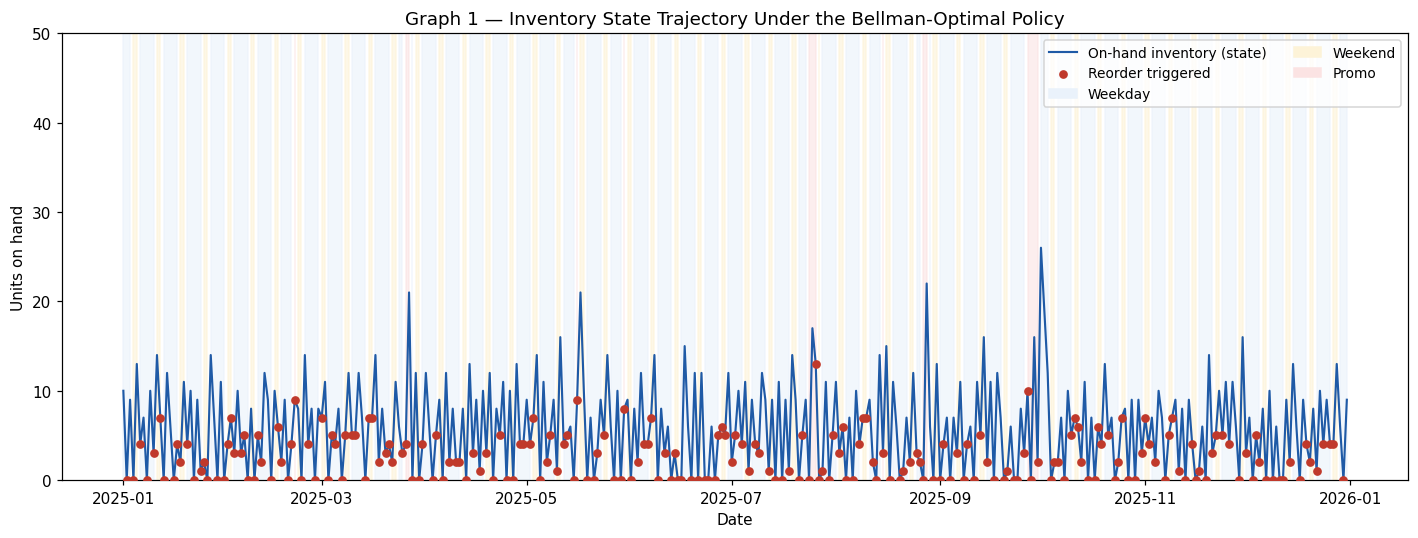

In [18]:
fig, ax = plt.subplots(figsize=(13, 5))

regime_colors = {"Weekday": "#EAF2FB", "Weekend": "#FDF3D8", "Promo": "#FBE3E3"}
for name, color in regime_colors.items():
    mask = episode_log["regime"] == name
    ax.fill_between(episode_log["date"], 0, I_MAX, where=mask, color=color, step="mid", alpha=0.6, zorder=0)

ax.plot(episode_log["date"], episode_log["state_inventory"], color="#1f5aa6", lw=1.4, label="On-hand inventory (state)")

reorder_days = episode_log[episode_log["action_order_qty"] > 0]
ax.scatter(reorder_days["date"], reorder_days["state_inventory"], color="#c0392b",
           s=22, zorder=5, label="Reorder triggered")

legend_patches = [mpatches.Patch(color=c, label=n) for n, c in regime_colors.items()]
ax.legend(handles=ax.get_legend_handles_labels()[0] + legend_patches, loc="upper right", fontsize=9, ncol=2)

ax.set_title("Graph 1 — Inventory State Trajectory Under the Bellman-Optimal Policy")
ax.set_xlabel("Date")
ax.set_ylabel("Units on hand")
ax.set_ylim(0, I_MAX)
plt.tight_layout()
plt.show()


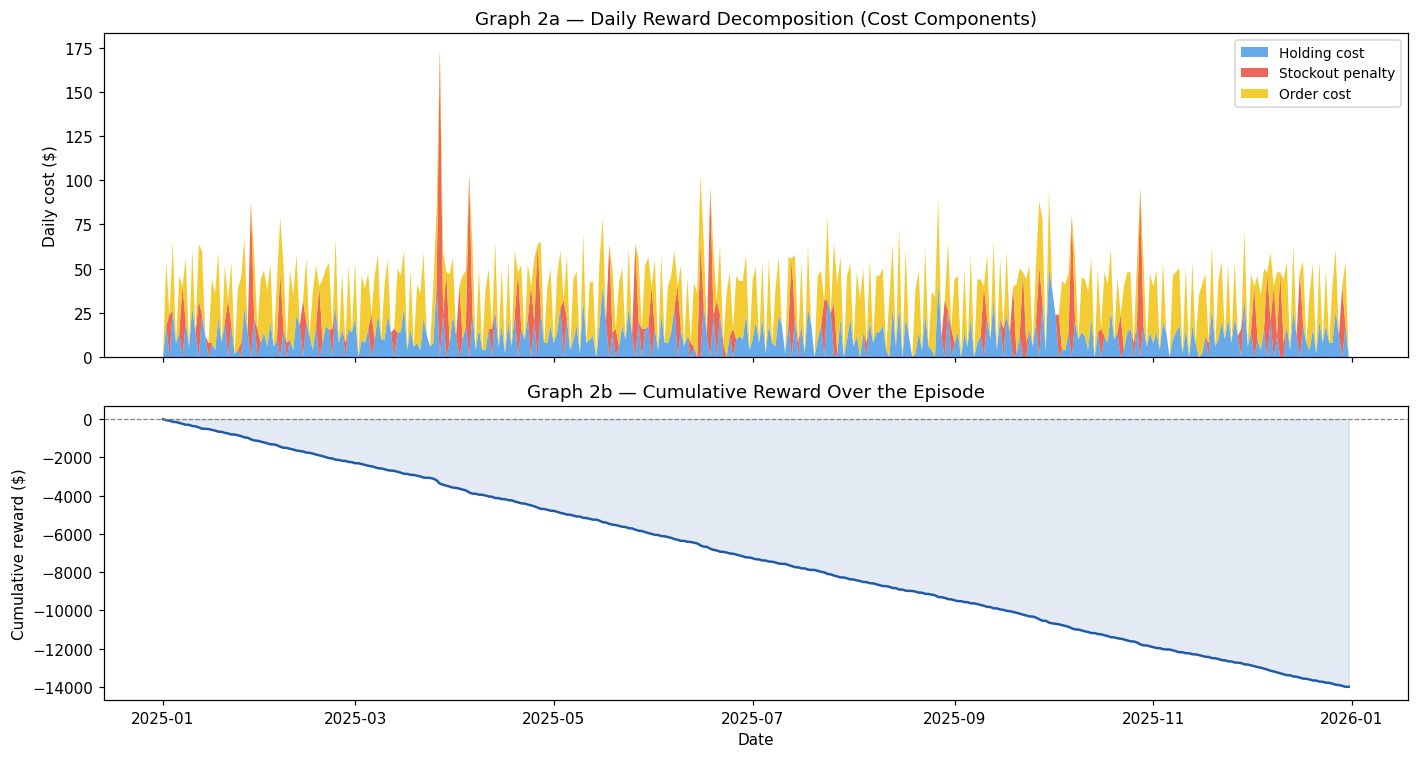

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios": [1.1, 1]})

ax1.stackplot(episode_log["date"],
              episode_log["holding_cost"], episode_log["stockout_penalty"], episode_log["order_cost"],
              labels=["Holding cost", "Stockout penalty", "Order cost"],
              colors=["#4c9be8", "#e74c3c", "#f1c40f"], alpha=0.85)
ax1.set_ylabel("Daily cost ($)")
ax1.set_title("Graph 2a — Daily Reward Decomposition (Cost Components)")
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(episode_log["date"], episode_log["cumulative_reward"], color="#1f5aa6", lw=1.6)
ax2.axhline(0, color="gray", lw=0.8, ls="--")
ax2.fill_between(episode_log["date"], episode_log["cumulative_reward"], 0, color="#1f5aa6", alpha=0.12)
ax2.set_ylabel("Cumulative reward ($)")
ax2.set_xlabel("Date")
ax2.set_title("Graph 2b — Cumulative Reward Over the Episode")

plt.tight_layout()
plt.show()


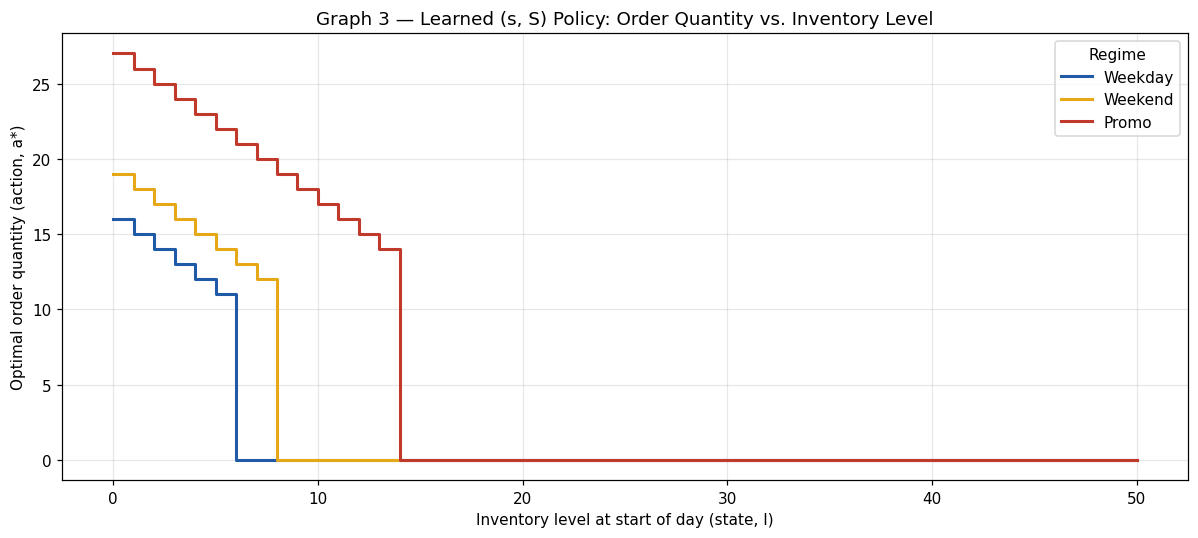

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = {"Weekday": "#1f5aa6", "Weekend": "#e6a817", "Promo": "#c0392b"}
inv_levels = np.arange(0, I_MAX + 1)

for name, idx in R_IDX.items():
    ax.step(inv_levels, policy_order_qty[idx], where="post", label=name, color=colors[name], lw=2)

ax.set_title("Graph 3 — Learned (s, S) Policy: Order Quantity vs. Inventory Level")
ax.set_xlabel("Inventory level at start of day (state, I)")
ax.set_ylabel("Optimal order quantity (action, a*)")
ax.legend(title="Regime")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


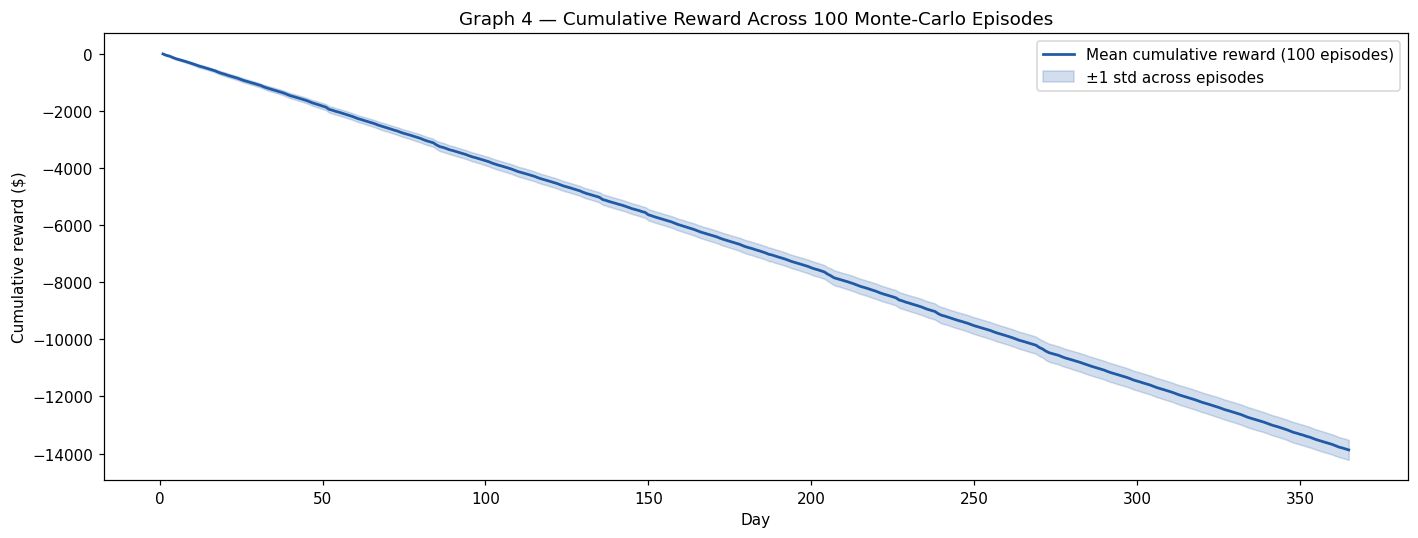

Final cumulative reward — mean: -13,872.88, std: 348.38


In [21]:
N_EPISODES = 100
rng = np.random.default_rng(7)
regime_seq = df["day_type"].to_numpy()
n_days = len(regime_seq)

cum_matrix = np.zeros((N_EPISODES, n_days))
for e in range(N_EPISODES):
    I = 10
    rewards = []
    for R in regime_seq:
        r_idx = R_IDX[R]
        D = rng.choice(D_MAX + 1, p=demand_pmf[r_idx])
        target = int(policy_order_upto[r_idx, I])
        order_qty = target - I
        available = I + order_qty
        leftover = max(0, available - D)
        shortfall = max(0, D - available)
        cost = (holding_cost[r_idx] * leftover + stockout_cost[r_idx] * shortfall
                + ORDER_FIXED_COST * (order_qty > 0) + ORDER_UNIT_COST * order_qty)
        rewards.append(-cost)
        I = min(leftover, I_MAX)
    cum_matrix[e] = np.cumsum(rewards)

mean_curve = cum_matrix.mean(axis=0)
std_curve  = cum_matrix.std(axis=0)
days = np.arange(1, n_days + 1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(days, mean_curve, color="#1f5aa6", lw=1.8, label="Mean cumulative reward (100 episodes)")
ax.fill_between(days, mean_curve - std_curve, mean_curve + std_curve,
                color="#1f5aa6", alpha=0.2, label="\u00b11 std across episodes")
ax.set_title("Graph 4 — Cumulative Reward Across 100 Monte-Carlo Episodes")
ax.set_xlabel("Day")
ax.set_ylabel("Cumulative reward ($)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Final cumulative reward — mean: {mean_curve[-1]:,.2f}, std: {std_curve[-1]:,.2f}")


In [23]:
import numpy as np
import pandas as pd

# --- load model + environment ---
model = np.load("inventory_bellman_model.npz", allow_pickle=True)
policy_order_upto = model["policy_order_upto"]
holding_cost      = model["holding_cost"]
stockout_cost     = model["stockout_cost"]
demand_pmf        = model["demand_pmf"]
REGIMES           = list(model["regimes"])
I_MAX             = int(model["I_MAX"])
D_MAX             = int(model["D_MAX"])
ORDER_FIXED_COST  = float(model["ORDER_FIXED_COST"])
ORDER_UNIT_COST   = float(model["ORDER_UNIT_COST"])
R_IDX = {n: i for i, n in enumerate(REGIMES)}

df = pd.read_csv("simulated_retail_demand.csv")
regime_seq = df["day_type"].to_numpy()

# --- run N Monte Carlo episodes through the learned policy ---
N_EPISODES = 200
rng = np.random.default_rng(7)
ep_rewards, ep_penalties, ep_avg_inv = [], [], []

for _ in range(N_EPISODES):
    I = 10
    rewards, penalties, invs = [], [], []
    for R in regime_seq:
        r = R_IDX[R]
        D = rng.choice(D_MAX + 1, p=demand_pmf[r])
        target = int(policy_order_upto[r, I])
        order_qty = target - I
        available = I + order_qty
        leftover  = max(0, available - D)
        shortfall = max(0, D - available)
        penalty = stockout_cost[r] * shortfall
        cost = holding_cost[r]*leftover + penalty + ORDER_FIXED_COST*(order_qty>0) + ORDER_UNIT_COST*order_qty
        rewards.append(-cost); penalties.append(penalty); invs.append(I)
        I = min(leftover, I_MAX)
    ep_rewards.append(sum(rewards))
    ep_penalties.append(sum(penalties))
    ep_avg_inv.append(np.mean(invs))

ep_rewards   = np.array(ep_rewards)
ep_penalties = np.array(ep_penalties)
ep_avg_inv   = np.array(ep_avg_inv)

# --- build the summary table ---
summary = {
    "Algorithm":               "Value Iteration (Bellman Equation)",
    "Environment":              "Retail Inventory (Markov-modulated demand)",
    "Number of States":         f"{(I_MAX+1) * len(REGIMES)}  ({I_MAX+1} inventory levels x {len(REGIMES)} regimes)",
    "Number of Actions":        f"Up to {I_MAX+1} (order 0-{I_MAX} units)",
    "Episodes":                  N_EPISODES,
    "Discount Factor (γ)":      float(model["GAMMA"]),
    "Fixed Order Cost (K)":     ORDER_FIXED_COST,
    "Variable Order Cost (c)":  ORDER_UNIT_COST,
    "Total Reward":              round(ep_rewards.sum(), 2),
    "Average Reward":           round(ep_rewards.mean(), 2),
    "Maximum Reward":           round(ep_rewards.max(), 2),
    "Minimum Reward":           round(ep_rewards.min(), 2),
    "Total Penalty":              round(ep_penalties.sum(), 2),
    "Average Penalty":          round(ep_penalties.mean(), 2),
    "Average Inventory":         round(ep_avg_inv.mean(), 2),
    "Policy Learned":            "Yes",
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])

# --- professional styled display ---
summary_df.style.set_properties(**{"text-align": "left", "font-size": "13px"}) \
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1f5aa6"), ("color", "white"),
                                       ("font-weight", "bold"), ("text-align", "left"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [("padding", "6px 10px"), ("border-bottom", "1px solid #ddd")]},
    ]).hide(axis="index")

FileNotFoundError: [Errno 2] No such file or directory: 'inventory_bellman_model.npz'

In [5]:
import pandas as pd

summary = {
    "Algorithm":               "Value Iteration (Bellman Equation)",
    "Environment":              "Retail Inventory (Markov-modulated demand)",
    "Number of States":         "153 (51 inventory levels x 3 regimes)",
    "Number of Actions":        "Up to 51 (order 0-50 units)",
    "Episodes":                  200,
    "Discount Factor (γ)":      0.95,
    "Fixed Order Cost (K)":     20.0,
    "Variable Order Cost (c)":  1.0,
    "Total Reward":             -2767115.81,
    "Average Reward":           -13835.58,
    "Maximum Reward":           -12826.58,
    "Minimum Reward":           -14704.95,
    "Total Penalty":             491820.15,
    "Average Penalty":          2459.10,
    "Average Inventory":         5.51,
    "Policy Learned":            "Yes",
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])

summary_df.style.set_properties(**{"text-align": "left", "font-size": "13px"}) \
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1f5aa6"), ("color", "white"),
                                       ("font-weight", "bold"), ("text-align", "left"), ("padding", "6px 10px")]},
        {"selector": "td", "props": [("padding", "6px 10px"), ("border-bottom", "1px solid #ddd")]},
    ]).hide(axis="index")

Metric,Value
Algorithm,Value Iteration (Bellman Equation)
Environment,Retail Inventory (Markov-modulated demand)
Number of States,153 (51 inventory levels x 3 regimes)
Number of Actions,Up to 51 (order 0-50 units)
Episodes,200
Discount Factor (γ),0.950000
Fixed Order Cost (K),20.000000
Variable Order Cost (c),1.000000
Total Reward,-2767115.810000
Average Reward,-13835.580000
